# Блок 7. Основы искусственного интеллекта и машинного обучения
## Занятие 6. Метрики классификации и Confusion Matrix

## Цель занятия

На прошлом занятии мы построили первую модель классификации через `LogisticRegression`.

Сегодня подробно разбираем, как оценивать качество классификатора.

Изучаем:

- `Confusion Matrix`;
- `TP`, `TN`, `FP`, `FN`;
- `Accuracy`;
- `Precision`;
- `Recall`;
- `F1-score`;
- визуализацию матрицы ошибок;
- анализ ошибок модели.

---

## Почему Accuracy недостаточно

Accuracy показывает долю правильных ответов.

Но иногда этого мало.

Пример:

Если в задаче 95% писем не спам, модель может всегда говорить «не спам» и получить Accuracy 95%.

Но такая модель бесполезна, потому что она не находит спам.

Поэтому нужны дополнительные метрики:

- Precision;
- Recall;
- F1-score.

---

## Confusion Matrix простыми словами

Матрица ошибок показывает, где модель ошиблась.

Для бинарной классификации есть 4 варианта:

| Обозначение | Смысл |
|---|---|
| TP | модель сказала 1, и правильный ответ 1 |
| TN | модель сказала 0, и правильный ответ 0 |
| FP | модель сказала 1, но правильный ответ 0 |
| FN | модель сказала 0, но правильный ответ 1 |

---

## Метрики

### Accuracy

Сколько всего ответов правильные.

### Precision

Из тех, кого модель назвала положительным классом, сколько действительно положительные.

### Recall

Из всех настоящих положительных объектов, сколько модель нашла.

### F1-score

Средний баланс между Precision и Recall.

---

## Датасет занятия

Используем встроенный датасет Breast Cancer из Scikit-Learn.

Задача:

- определить класс медицинского объекта по числовым признакам;
- построить модель классификации;
- оценить качество модели.

---

## Связь с дипломом

Метрики классификации нужны в проектах:

- медицина: болен / здоров;
- HR: подходит / не подходит;
- банк: рискованный клиент / надёжный клиент;
- продажи: купит / не купит;
- безопасность: мошенничество / обычная операция.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/block7-lesson06-classification-metrics

git add .
git commit -m "feat: add classification metrics lesson"
git push -u origin feature/block7-lesson06-classification-metrics
```


Сначала изучите SOLVED-ноутбук вместе с преподавателем. Затем выполните TODO самостоятельно.

## Ячейка 1. TODO: импорт библиотек

### Алгоритм

Импортируйте pandas, matplotlib, Scikit-Learn инструменты и метрики классификации.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Библиотеки подключены")

assert pd is not None

Библиотеки подключены


## Ячейка 2. TODO: загрузка датасета

### Алгоритм

Загрузите Breast Cancer, создайте X и y, проверьте размеры.

In [22]:
import pandas as pd
from IPython.display import display

url = "../../data/daily_meal_table.csv"
df: pd.DataFrame = pd.read_csv(url)


#'energy_kcal', "products"
feature_cols = [ 'protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g',
                'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g', ]
target_col = "is_main_meal"

df[target_col] = (df["meal"] != "breakfast").astype("int8")

print(df.shape)
display(df.head())

assert target_col in df.columns
assert len(df) > 1000
assert df.shape[1] == 16

X: pd.DataFrame = pd.DataFrame(df, columns=feature_cols)
y: pd.Series = pd.Series(df[target_col])


assert len(X) == len(y)

(15322, 16)


,id,date,meal,products,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g,is_main_meal
0,0060b6899180e194092d60a0e50aeea1,2019/2/22,breakfast,2,615.0,16.39,17.35,102.97,9.4,28.38,2.796,16.0,954.0,165.0,50.60,0
1,0060b6899180e194092d60a0e50aeea1,2019/2/22,lunch,3,564.0,33.00,10.00,85.40,8.2,0.00,0.555,0.0,248.0,739.0,164.80,1
2,0060b6899180e194092d60a0e50aeea1,2019/2/22,supper,2,239.0,15.73,10.53,22.27,1.9,3.85,1.780,28.0,536.0,128.0,84.00,1
3,0060b6899180e194092d60a0e50aeea1,2019/2/23,breakfast,3,968.0,17.68,50.74,110.79,8.2,2.00,8.091,20.0,1600.0,563.0,115.20,0
4,0060b6899180e194092d60a0e50aeea1,2019/2/23,lunch,3,487.0,16.27,6.06,92.61,7.3,2.79,1.040,12.0,512.0,614.0,182.47,1


## Ячейка 3. TODO: распределение классов

### Алгоритм

Посчитайте классы, постройте bar chart и проверьте сумму.

Распределение классов:
is_main_meal
0     5157
1    10165
Name: count, dtype: int64


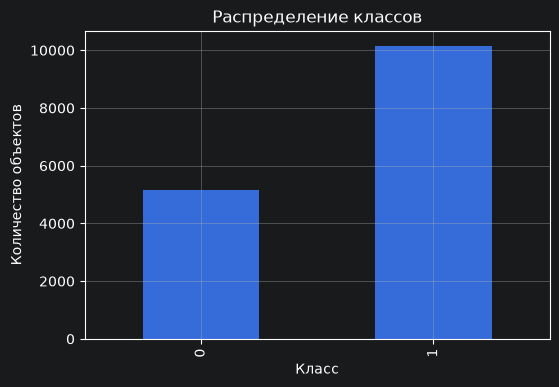

In [23]:
class_counts = y.value_counts().sort_index()

print("Распределение классов:")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.grid(True)
plt.show()

assert len(class_counts) == 2
assert class_counts.sum() == len(y)

## Ячейка 4. TODO: train/test split

### Алгоритм

Разделите данные на train/test с stratify=y.

In [24]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=df["id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
assert abs(len(X_train) / len(X_test) - 4) < 1

Train: (12358, 10)
Test: (2964, 10)


## Ячейка 5. TODO: масштабирование и обучение

### Алгоритм

Обучите StandardScaler на train, преобразуйте test, обучите LogisticRegression.

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

print("Модель обучена")

assert X_train_scaled.shape == X_train.shape
assert model is not None

Модель обучена


## Ячейка 6. TODO: предсказания

### Алгоритм

Получите y_pred, y_proba и таблицу сравнения факта и прогноза.

In [26]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

comparison = pd.DataFrame({
    "fact": y_test.values,
    "prediction": y_pred,
    "probability_class_1": y_proba[:, 1]
})

display(comparison.head(10))

assert len(y_pred) == len(y_test)
assert y_proba.shape[1] == 2

,fact,prediction,probability_class_1
0,0,0,0.474709
1,1,1,0.908109
2,1,1,0.706370
3,0,1,0.732345
4,1,1,0.651391
5,1,1,0.692172
6,0,0,0.169895
7,1,1,0.766558
8,1,1,0.767554
9,0,0,0.169895


## Ячейка 7. TODO: основные метрики

### Алгоритм

Посчитайте Accuracy, Precision, Recall и F1-score.

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_report = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

for key, value in metrics_report.items():
    print(key, ":", round(value, 4))

assert accuracy > 0.8
assert f1 > 0.8

accuracy : 0.8171
precision : 0.8308
recall : 0.9094
f1 : 0.8683


## Ячейка 8. TODO: Confusion Matrix

### Алгоритм

Постройте матрицу ошибок и получите TN, FP, FN, TP.

In [28]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

assert cm.sum() == len(y_test)

Confusion Matrix:
[[ 635  364]
 [ 178 1787]]
TN: 635
FP: 364
FN: 178
TP: 1787


## Ячейка 9. TODO: визуализация матрицы ошибок

### Алгоритм

Используйте ConfusionMatrixDisplay и classification_report.

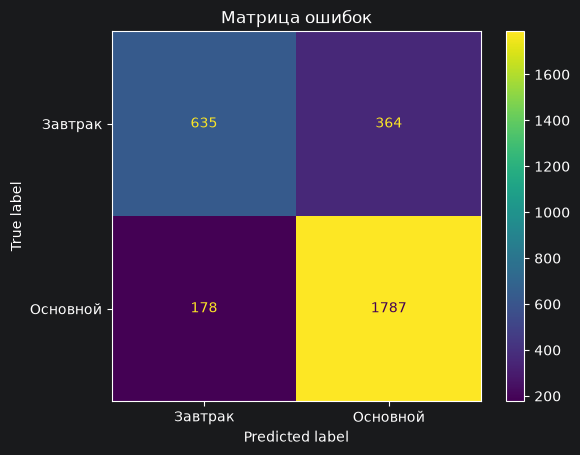

Classification Report:
              precision    recall  f1-score   support

     Завтрак       0.78      0.64      0.70       999
    Основной       0.83      0.91      0.87      1965

    accuracy                           0.82      2964
   macro avg       0.81      0.77      0.78      2964
weighted avg       0.81      0.82      0.81      2964



In [32]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Завтрак", "Основной"]
)

disp.plot()
plt.title("Матрица ошибок")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Завтрак", "Основной"]))

assert True

## Ячейка 10. TODO: итоговый ML-отчёт

### Алгоритм

Соберите словарь final_report, выводы и GitHub-команды.

In [34]:
final_report = {
    "rows": len(X),
    "features": X.shape[1],
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1": round(f1, 4),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

print("Итоговый отчёт:")
for key, value in final_report.items():
    print(key, ":", value)

conclusions = [
    "Accuracy показывает общую долю правильных ответов.",
    "Precision показывает точность положительных предсказаний.",
    "Recall показывает, сколько положительных объектов модель нашла.",
    "F1-score помогает оценить баланс Precision и Recall.",
    "Confusion Matrix помогает увидеть конкретные типы ошибок модели."
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

print()
print("GitHub:")
print("git add .")
print('git commit -m "feat: complete classification metrics lesson"')
print("git push -u origin feature/block7-lesson06-classification-metrics")

assert final_report["features"] > 1
assert len(conclusions) == 5

Итоговый отчёт:
rows : 15322
features : 10
accuracy : 0.8171
precision : 0.8308
recall : 0.9094
f1 : 0.8683
tn : 635
fp : 364
fn : 178
tp : 1787

Выводы:
- Accuracy показывает общую долю правильных ответов.
- Precision показывает точность положительных предсказаний.
- Recall показывает, сколько положительных объектов модель нашла.
- F1-score помогает оценить баланс Precision и Recall.
- Confusion Matrix помогает увидеть конкретные типы ошибок модели.

GitHub:
git add .
git commit -m "feat: complete classification metrics lesson"
git push -u origin feature/block7-lesson06-classification-metrics


# Итог TODO-задания

Покажите преподавателю:

- распределение классов;
- модель классификации;
- предсказания и вероятности;
- Accuracy, Precision, Recall, F1;
- Confusion Matrix;
- `classification_report`;
- итоговый ML-отчёт.